In [6]:
import sys
if '/disks/cosmodm/vdvuurst' not in sys.path:
    sys.path.append('/disks/cosmodm/vdvuurst')

import numpy as np
import h5py
from matplotlib import pyplot as plt
import os
from importlib import reload
import json
import ONEHALO
from tqdm import tqdm
from functions import modified_logspace, BIC
from onehalo_plotter import *
from functional_forms import *
format_plot()

from scipy.optimize import minimize

In [2]:
np.random.seed(42)
combi_subsample_idx = np.random.choice(len(all_combis),size = len(all_combis)//100) #1% subsample 
all_combis = np.array(all_combis, dtype=object)
combi_subsample = all_combis[combi_subsample_idx]
combi_subsample_names = np.array(all_names, dtype = object)[combi_subsample_idx]
print(f'There are {combi_subsample.shape[0]} function combinations')

There are 92 function combinations


In [ ]:
# n_params_r, n_params_m = jointfitter.fit_to_data(combi_subsample[0])
function_combi = combi_subsample[0]
print(function_combi)

def param_info(function_combi):
    # Generate parameter information lists (pointers) given a function combination
    n_params_r = []
    n_params_m = [] # every list is for a double gauss parameter, containing a number of parameters needed to parametrize an r-parameter in terms of M for every r-parameter
    for i,param_combi in enumerate(function_combi):
        _, m_parametrizations = param_combi # unpack the function combination for this specific parameter
        n_params_r.append(len(m_parametrizations))
        n_params_m.append([len(signature(m_func).parameters) - 1 for m_func in m_parametrizations])

    n_params_m = flatten(n_params_m)

    return n_params_r, n_params_m

n_params_r, n_params_m = param_info(function_combi)

print(f'{n_params_m = }')

nparams = sum(n_params_m)
print(f'Total of {nparams} parameters.')

mbin = 12.25
rbin = 0.035

mass_filepath = '/disks/cosmodm/vdvuurst/data/Onehalo_M_12-15.5_subsampled.hdf5'
with h5py.File(mass_filepath) as handle:
    halo_masses = handle['mass'][:]
    # rel_pos = handle['rel_pos'][:]
    rel_vels = handle['rel_vels'][:]
    rel_dist = handle['rel_dist'][:]
    
Nv, Nmr = rel_vels.size, rel_vels.shape[0]

# np.random.seed(42)
params = np.random.randint(-100,100,size = (nparams,)).astype(np.float32)
print(params.shape)
print()
# lambda_n, sigma1_n, sigma2_n = n_params_m

def double_gauss_prior_check(param, param_str):
    match param_str.lower():
        case 'sigma_1':
            prior = GLOBAL_PRIOR_RANGE[0][0] <= param <= GLOBAL_PRIOR_RANGE[0][1]
            return prior
        case 'sigma_2':
            prior = GLOBAL_PRIOR_RANGE[1][0] <= param <= GLOBAL_PRIOR_RANGE[1][1]
            return prior
        case 'lambda':
            prior = GLOBAL_PRIOR_RANGE[2][0] <= param <= GLOBAL_PRIOR_RANGE[2][1]
            return prior

param_names = ['sigma_1', 'sigma_2', 'lambda']


[[<function poly_4_func at 0x7f8d2315de40>
  (<function linear_func at 0x7f8d2315d9e0>, <function parabola_func at 0x7f8d2315d8a0>, <function exponential_func at 0x7f8d2315da80>, <function exponential_func at 0x7f8d2315da80>, <function exponential_func at 0x7f8d2315da80>)]
 [<function parabola_func at 0x7f8d2315d8a0>
  (<function linear_func at 0x7f8d2315d9e0>, <function linear_func at 0x7f8d2315d9e0>, <function linear_func at 0x7f8d2315d9e0>)]
 [<function exponential_func at 0x7f8d2315da80>
  (<function parabola_func at 0x7f8d2315d8a0>, <function parabola_func at 0x7f8d2315d8a0>, <function parabola_func at 0x7f8d2315d8a0>)]]
n_params_m = [2, 3, 3, 3, 3, 2, 2, 2, 3, 3, 3]
Total of 29 parameters.
(29,)



In [11]:
# dictionary that, given a function in r, knows what to set the parameters to for a decent starting position
r_function_dict = {'poly_4':[0,0,0,0,50], 'poly_3':[0,0,0,150], 
                    'parabola':[0,0,5], 'linear':[0,5], 'exponential':[0,0,0.1], 'inverse':[0,0.4]}
m_func_n_params_dict = {'linear': 2, 'parabola': 3, 'exponential': 3}

def init_conditions(combi_names):
    initial_conditions = []
    for rfunc, mfuncs in combi_names:
        # r_param_values = r_function_dict[rfunc]

        for rparam_value, mfunc in zip(r_function_dict[rfunc], mfuncs):
            if rparam_value == 0:
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc])]
            else: 
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc] - 1)]
                mfunc_values.append(rparam_value) # last value (constant term) is equal with all other parameters set to 0

            initial_conditions.extend(mfunc_values)
    
    return initial_conditions


combi_nr = 2 # not an index
test_func_combi = combi_subsample[combi_nr - 1]
test_func_combi_names = combi_subsample_names[combi_nr - 1]
test_func_combi_names = [list(t) for t in test_func_combi_names]

n_params_r, n_params_m = param_info(test_func_combi)
init_pos = init_conditions(test_func_combi_names)
# print(init_pos)

reload(ONEHALO)

joint_fitter =  ONEHALO.ONEHALO_joint_fitter() # loads in the data and has functions to work with that use the data
DG_params = joint_fitter.get_double_gauss_parameters(joint_fitter.split_parameters(init_pos, n_params_m), test_func_combi, n_params_r)

prior = log_prior_vec(DG_params) # all good
prior_mask = np.isfinite(prior)
prior_data = joint_fitter.min_half_v_sq_arr[prior_mask]

sigma1, sigma2, lambda_ = DG_params[:, prior_mask]
# sigma1 *= 0.1
print(sigma1, sigma2, lambda_)
norm = 1 / (((1- lambda_) * sigma1 + lambda_ * sigma2)* np.sqrt(2 * np.pi)) # independent of v, so move here
sigma1_sq_inv = 1/ (2 * sigma1**2)
sigma2_sq_inv = 1 / (2* sigma2**2)
one_min_lambda = 1 - lambda_

logL = mod_gaussian_log_likelihood_vec(DG_params, rel_vels)
logL

[150. 150. 150. ... 150. 150. 150.] [5. 5. 5. ... 5. 5. 5.] [0.4 0.4 0.4 ... 0.4 0.4 0.4]


np.float64(34491.66385809032)

In [ ]:
# dictionary that, given a function in r, knows what to set the parameters to for a decent starting position
r_function_dict = {'poly_4':[0,0,0,0,50], 'poly_3':[0,0,0,150], 
                    'parabola':[0,0,5], 'linear':[0,5], 'exponential':[0,0,0.1], 'inverse':[0,0.4]}
m_func_n_params_dict = {'linear': 2, 'parabola': 3, 'exponential': 3}

combi_nr = 2 # not an index
test_func_combi = combi_subsample[combi_nr - 1]
test_func_combi_names = combi_subsample_names[combi_nr - 1]
test_func_combi_names = [list(t) for t in test_func_combi_names]

def _init_conditions(combi_names):
    initial_conditions = []
    for rfunc, mfuncs in combi_names:
        # r_param_values = r_function_dict[rfunc]

        for rparam_value, mfunc in zip(r_function_dict[rfunc], mfuncs):
            if rparam_value == 0:
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc])]
            else: 
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc] - 1)]
                mfunc_values.append(rparam_value) # last value (constant term) is equal with all other parameters set to 0

            initial_conditions.extend(mfunc_values)
    
    return initial_conditions

def find_starting_point(function_combi, combi_names, joint_fitter: ONEHALO.ONEHALO_joint_fitter):
    # Get very simple initial conditions (mostly zeroes) and necessary infotmation from function combination
    initial_conditions = _init_conditions(combi_names)    
    n_params_r, n_params_m = param_info(function_combi)
    
    # Call from the joint_fitter object since it has data loaded in which is deeded to get the DG param values
    minimize_func = lambda *x: -joint_fitter.get_joint_likelihood(*x) # the original likelihood function maximizes, we want to minimize of course
    res = minimize(minimize_func, initial_conditions, args = ( n_params_m, n_params_r, function_combi), method = 'BFGS')
    return res.x

find_starting_point(test_func_combi, test_func_combi_names, joint_fitter)
    

Minimize has found the same array again: False


array([-7.49983057e-11,  0.00000000e+00, -6.59606957e-11,  0.00000000e+00,
        3.56555409e-02, -7.51214758e-11,  0.00000000e+00, -5.09473502e-06,
       -1.22708264e-10,  1.50000000e+02,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  5.00000000e+00,
        1.12846625e-02,  1.11622950e-11,  0.00000000e+00,  0.00000000e+00,
        4.00000000e-01])

In [23]:
combi_subsample[0]

array([[<function poly_4_func at 0x7f8d2315de40>,
        (<function linear_func at 0x7f8d2315d9e0>, <function parabola_func at 0x7f8d2315d8a0>, <function exponential_func at 0x7f8d2315da80>, <function exponential_func at 0x7f8d2315da80>, <function exponential_func at 0x7f8d2315da80>)],
       [<function parabola_func at 0x7f8d2315d8a0>,
        (<function linear_func at 0x7f8d2315d9e0>, <function linear_func at 0x7f8d2315d9e0>, <function linear_func at 0x7f8d2315d9e0>)],
       [<function exponential_func at 0x7f8d2315da80>,
        (<function parabola_func at 0x7f8d2315d8a0>, <function parabola_func at 0x7f8d2315d8a0>, <function parabola_func at 0x7f8d2315d8a0>)]],
      dtype=object)

/disks/cosmodm/vdvuurst/functional_forms.py:15: RuntimeWarning: overflow encountered in exp
  return A * exp(-B * x) + C
/disks/cosmodm/vdvuurst/ONEHALO.py:668: RuntimeWarning: overflow encountered in cast
  double_gauss_params[i] = param_values
/disks/cosmodm/vdvuurst/functional_forms.py:9: RuntimeWarning: invalid value encountered in add
  return m * x + c
  4%|▍         | 11/250 [00:02<00:50,  4.77it/s]/disks/cosmodm/vdvuurst/functional_forms.py:15: RuntimeWarning: overflow encountered in multiply
  return A * exp(-B * x) + C
  6%|▌         | 15/250 [00:03<00:54,  4.32it/s]/disks/cosmodm/vdvuurst/functional_forms.py:9: RuntimeWarning: overflow encountered in multiply
  return m * x + c
100%|██████████| 250/250 [00:53<00:00,  4.63it/s]


[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.000000

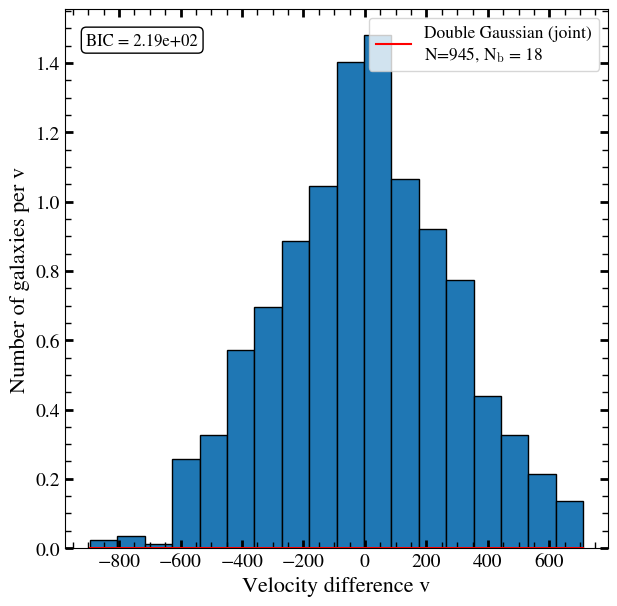

In [5]:
reload(ONEHALO)

joint_test = ONEHALO.ONEHALO_joint_fitter()
combi_nr = 2 # not an index
test_func_combi = combi_subsample[combi_nr - 1]
test_func_combi_names = combi_subsample_names[combi_nr - 1]
test_func_combi_names = [list(t) for t in test_func_combi_names]
n_params_r, n_params_m = param_info(test_func_combi)

nwalkers = 50
nsteps = 250
init_pos = init_conditions(test_func_combi_names)
init_guess = np.random.normal(loc = init_pos, scale = 0.01, size = (nwalkers, sum(n_params_m)))

joint_test.fit_function_combi_to_data(test_func_combi, test_func_combi_names, combi_nr, nwalkers, nsteps,
                                        init_guess, verbose = True, plot = True, show_plot = True,
                                        mbin = [3.0, 3.5], rbin = [0.07, 0.14])